# 1. Introducción y Objetivos
El presente análisis tiene como propósito explorar el comportamiento de la cartera de préstamos y su relación con el historial de pagos. 

**Objetivos principales:**
* **Perfilamiento:** Entender la estructura y calidad de los datos de `cartera` y `pagos`.
* **Identificación de factores:** Detectar variables que presenten una correlación significativa con el riesgo (`dias_mora`).
* **Preparación:** Generar los *insights* necesarios para la etapa de modelado predictivo.

In [36]:
import numpy as np
import pandas as pd
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Ingesta y Validación de Datos
En esta etapa, realizamos la carga de los archivos de datos (`cartera` y `pagos`) para validar su estructura, tipologías y consistencia inicial.

In [ ]:
file_path = '../data/raw/datasets_riesgo_v2.xlsx'

df_cartera = pd.read_excel(file_path, sheet_name='cartera', decimal=',')
df_pagos = pd.read_excel(file_path, sheet_name='pagos', decimal=',')

print(f"Cartera cargada: {df_cartera.shape[0]} registros.")
print(f"Pagos cargados: {df_pagos.shape[0]} registros.")


Cartera cargada: 400 registros.
Pagos cargados: 1349 registros.


* **Estado de la carga:** Se importaron exitosamente 400 registros en la tabla de `cartera` y 1349 registros en la tabla de `pagos`.

In [37]:
print("Información de Cartera:")
df_cartera.info()

Información de Cartera:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_prestamo        400 non-null    int64  
 1   id_cliente         400 non-null    int64  
 2   producto           400 non-null    object 
 3   fecha_originacion  400 non-null    object 
 4   monto_original     400 non-null    int64  
 5   plazo_meses        400 non-null    int64  
 6   tna                400 non-null    float64
 7   segmento_cliente   400 non-null    object 
 8   canal_adquisicion  400 non-null    object 
 9   pais               400 non-null    object 
 10  estado_actual      400 non-null    object 
 11  dias_mora          400 non-null    int64  
 12  saldo_capital      400 non-null    float64
dtypes: float64(2), int64(5), object(6)
memory usage: 40.8+ KB


In [38]:
print("\nInformación de Pagos:")
df_pagos.info()


Información de Pagos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pago            1349 non-null   int64  
 1   id_prestamo        1349 non-null   int64  
 2   nro_cuota          1349 non-null   int64  
 3   fecha_vencimiento  1349 non-null   object 
 4   monto_cuota        1349 non-null   float64
 5   fecha_pago_real    1198 non-null   object 
 6   monto_pagado       1349 non-null   float64
 7   dias_atraso        1198 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 84.4+ KB


### Normalización de Tipos de Datos
Tras la carga inicial, es fundamental convertir las columnas de fechas (`fecha_vencimiento`, `fecha_pago_real`, `fecha_originacion`) de tipo `object` a `datetime`.

In [39]:
df_pagos['fecha_vencimiento'] = pd.to_datetime(df_pagos['fecha_vencimiento'])
df_pagos['fecha_pago_real'] = pd.to_datetime(df_pagos['fecha_pago_real'])
df_cartera['fecha_originacion'] = pd.to_datetime(df_cartera['fecha_originacion'])

In [41]:
def mostrar_descripcion(df, nombre):
    print(f"Descripción de la tabla {nombre}:")
    display(df.describe())

mostrar_descripcion(df_cartera, 'de cartera')
mostrar_descripcion(df_pagos, 'de pagos')

Descripción de la tabla de cartera:


,id_prestamo,id_cliente,fecha_originacion,monto_original,plazo_meses,tna,dias_mora,saldo_capital
count,400.000000,400.000000,400,400.000000,400.000000,400.000000,400.000000,400.000000
mean,10199.500000,1127.135000,2023-03-29 13:12:00,19716.000000,6.440000,0.438200,27.620000,10181.249900
min,10000.000000,1000.000000,2022-01-01 00:00:00,700.000000,1.000000,0.300000,0.000000,0.000000
25%,10099.750000,1068.000000,2022-09-08 00:00:00,6900.000000,2.000000,0.345000,0.000000,2303.942500
50%,10199.500000,1128.000000,2023-03-23 12:00:00,13000.000000,5.000000,0.480000,0.000000,5533.160000
75%,10299.250000,1189.000000,2023-11-09 18:00:00,23425.000000,9.000000,0.480000,33.000000,12555.582500
max,10399.000000,1248.000000,2024-06-29 00:00:00,80000.000000,24.000000,0.620000,288.000000,76173.540000
std,115.614301,70.038527,NaN,19451.591323,5.657421,0.120661,56.391894,12605.102565


Descripción de la tabla de pagos:


,id_pago,id_prestamo,nro_cuota,fecha_vencimiento,monto_cuota,fecha_pago_real,monto_pagado,dias_atraso
count,1349.000000,1349.000000,1349.000000,1349,1349.000000,1198,1349.000000,1198.000000
mean,50674.000000,10205.333580,3.330615,2023-06-25 17:17:34.114158592,3569.413580,2023-07-03 05:54:35.459098368,2794.711490,4.793823
min,50000.000000,10000.000000,1.000000,2022-01-31 00:00:00,210.330000,2022-02-01 00:00:00,0.000000,0.000000
25%,50337.000000,10106.000000,1.000000,2022-11-22 00:00:00,1348.050000,2022-11-29 00:00:00,828.240000,0.000000
50%,50674.000000,10208.000000,3.000000,2023-06-20 00:00:00,2612.240000,2023-07-02 12:00:00,2017.990000,0.000000
75%,51011.000000,10309.000000,5.000000,2024-02-06 00:00:00,4206.670000,2024-02-09 00:00:00,3618.890000,4.000000
max,51348.000000,10399.000000,12.000000,2025-03-03 00:00:00,72176.000000,2025-03-03 00:00:00,64573.530000,45.000000
std,389.567067,115.657769,2.476379,NaN,4667.248702,NaN,4013.152835,9.987966


### Conclusiones del Perfilamiento
Tras observar los estadísticos descriptivos, destaco los siguientes puntos clave:

* **Alta Volatilidad en Mora (Cartera):** La variable `dias_mora` presenta una desviación estándar de **56.39** frente a una media de **27.62**. Esto indica que la mora no se distribuye uniformemente; existen casos extremos que elevan significativamente la dispersión.
* **Integridad de datos:** Se observa un conteo de registros inferior en `dias_atraso` (1198) comparado con el total de pagos (1349). **Acción requerida:** Imputar nulos en `dias_atraso` como 0 (asumiendo pago puntual) previo al análisis bivariante.
* **Distribución de saldos:** El rango del `saldo_capital` es amplio (0 a 76,173), confirmando la presencia de préstamos de diversos tamaños que deberán ser gestionados como potenciales *outliers* en el modelo.
* **Anomalía en Pagos:** Se identificaron registros con `monto_pagado` igual a **0.00**. **Acción requerida:** Investigar si estos representan intentos de pago fallidos, errores de carga o cuotas impagas que requieran un tratamiento específico.

## 3. Análisis Exploratorio Univariante

En esta sección, analizamos la distribución de las variables clave para entender su comportamiento, detectar sesgos y validar la presencia de valores atípicos (*outliers*) que puedan impactar en nuestro futuro modelo predictivo.

### 3.1. Distribución de la Morosidad
A continuación, analizamos la variable `dias_mora` para entender cómo se agrupan los clientes según su comportamiento de pago.

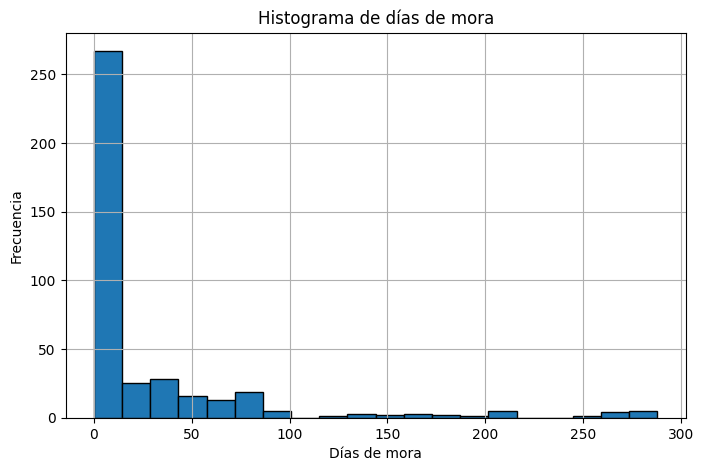

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df_cartera['dias_mora'].hist(bins=20, edgecolor='black')
plt.title('Histograma de días de mora')
plt.xlabel('Días de mora')
plt.ylabel('Frecuencia')
plt.show()

**Interpretación y hallazgos:**
* **Observación:** La gran mayoría de los créditos presentan 0 días de mora, lo cual es positivo para la salud de la cartera.
* **Comportamiento:** Existe una "cola" de distribución significativa que se extiende hasta casi 300 días, lo que evidencia una alta asimetría positiva en la morosidad.
* **Acción:** Dado el sesgo extremo, consideraremos categorizar esta variable en niveles de riesgo (ej: "Sin mora", "Mora temprana", "Mora crítica") para el modelo.

### 3.2. Análisis de Atípicos (Outliers) en Saldo Capital
Analizamos la variable `saldo_capital` mediante un diagrama de caja para identificar préstamos con montos inusualmente altos.

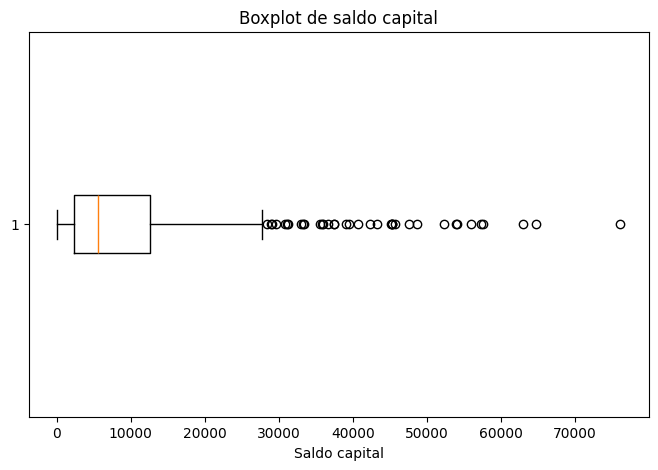

In [43]:
plt.figure(figsize=(8, 5))
plt.boxplot(df_cartera['saldo_capital'], vert=False)
plt.title('Boxplot de saldo capital')
plt.xlabel('Saldo capital')
plt.show()

**Interpretación y hallazgos:**
* **Observación:** La caja del gráfico se concentra en valores bajos, pero observamos una gran cantidad de puntos (círculos) a la derecha, confirmando la presencia de *outliers* significativos.
* **Impacto:** Estos préstamos de gran magnitud podrían distorsionar los resultados de una regresión lineal simple.
* **Acción:** Evaluar el impacto de estos *outliers* y considerar transformaciones logarítmicas o filtrado de casos extremos antes de proceder al entrenamiento del modelo.

## 4. Análisis Bivariante: Factores de Riesgo

En esta sección, exploramos las relaciones entre las variables independientes y nuestro objetivo (`dias_mora`). El propósito es identificar qué variables presentan una relación directa con el comportamiento de pago y justificar su inclusión en el modelo predictivo.

### 4.1. Relación: Saldo Capital vs. Días de Mora
Analizamos si el monto pendiente de pago influye en el retraso del cliente.

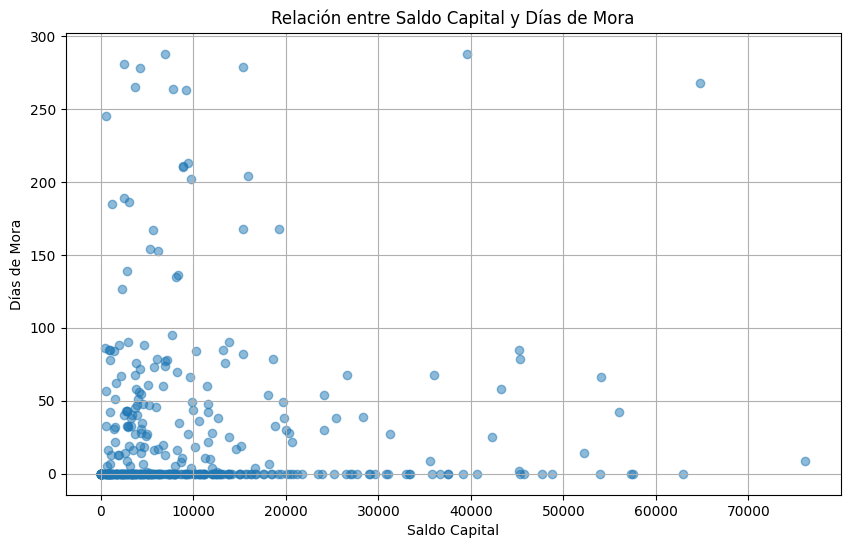

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cartera['saldo_capital'], df_cartera['dias_mora'], alpha=0.5)
plt.title('Relación entre Saldo Capital y Días de Mora')
plt.xlabel('Saldo Capital')
plt.ylabel('Días de Mora')
plt.grid(True)
plt.show()

**Interpretación y hallazgos:**
* **Observación:** No se observa una correlación lineal directa entre el saldo capital y los días de mora. Existe una alta densidad de clientes al día (0 mora) independientemente del nivel de saldo.
* **Insight:** El riesgo de mora parece ser independiente del tamaño del préstamo, lo cual sugiere que factores externos o de comportamiento histórico tienen mayor peso que el monto en sí mismo.

### 4.2. Relación: Tasa Nominal Anual (TNA) vs. Días de Mora
Evaluamos si la tasa de interés aplicada es un determinante del riesgo.

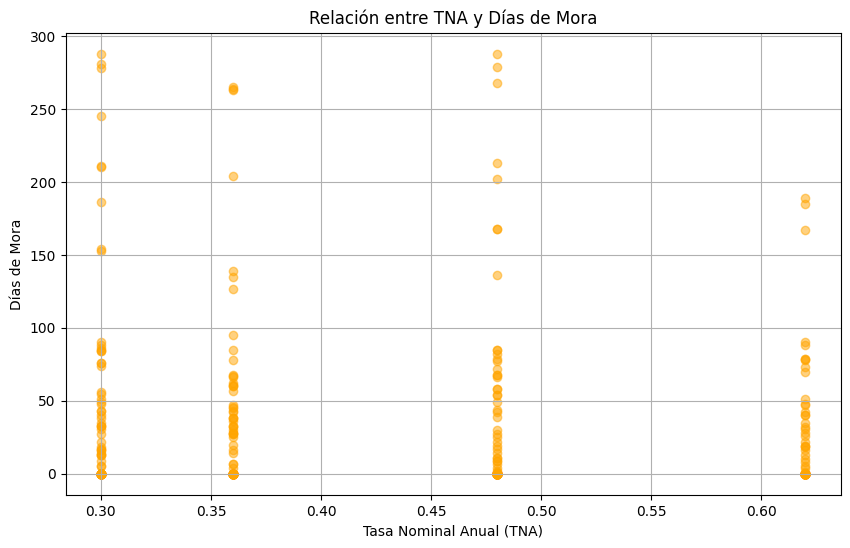

In [45]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cartera['tna'], df_cartera['dias_mora'], alpha=0.5, color='orange')
plt.title('Relación entre TNA y Días de Mora')
plt.xlabel('Tasa Nominal Anual (TNA)')
plt.ylabel('Días de Mora')
plt.grid(True)
plt.show()

**Interpretación y hallazgos:**
* **Observación:** La variable TNA muestra agrupaciones (clusters) en valores específicos (0.30, 0.36, 0.48, 0.62), lo que indica políticas de tasas estandarizadas por la empresa.
* **Insight:** La dispersión de la mora es similar a través de todos los niveles de tasa, lo que confirma que la TNA por sí sola no es un predictor determinante.
* **Conclusión:** Ambos análisis nos llevan a la necesidad de realizar *Feature Engineering* (ingeniería de variables) sobre la tabla de `pagos`, ya que las variables estáticas actuales no explican satisfactoriamente la variabilidad de la mora.

## 5. Examen de Correlación

El objetivo de esta matriz es identificar relaciones lineales entre las variables y detectar problemas de **multicolinealidad** que podrían afectar la estabilidad de un futuro modelo predictivo.

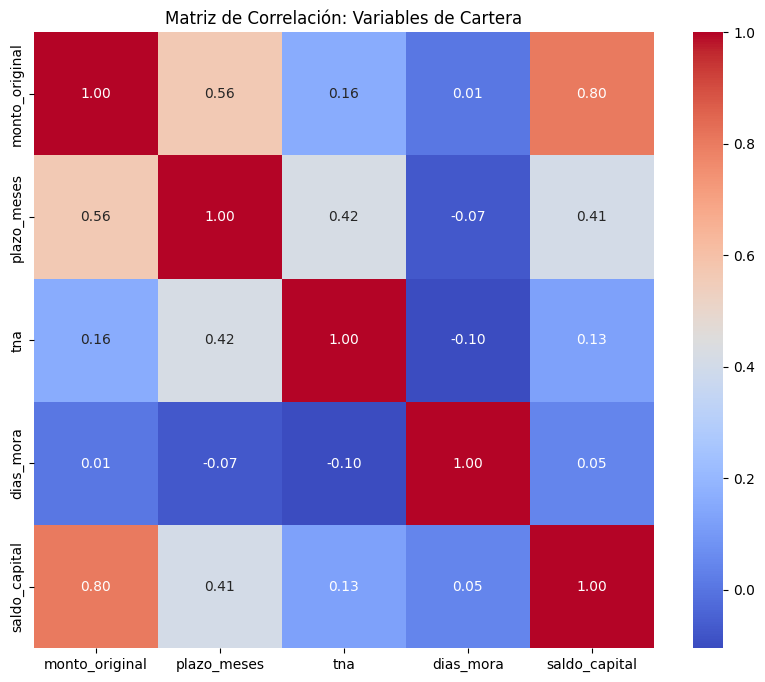

In [46]:
# Seleccionamos solo las columnas numéricas para la matriz
columnas_interes = ['monto_original', 'plazo_meses', 'tna', 'dias_mora', 'saldo_capital']
matriz_corr = df_cartera[columnas_interes].corr()

# Dibujamos el Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: Variables de Cartera')
plt.show()

### Interpretación y Hallazgos

* **Multicolinealidad Detectada:** Se observa una correlación alta (**0.80**) entre `monto_original` y `saldo_capital`.
    * **Acción:** Dado que ambas variables aportan información redundante, en la etapa de modelado se recomienda **eliminar `monto_original`** y conservar `saldo_capital`, ya que este último representa el estado actual del préstamo.
* **Debilidad Predictiva:** Al analizar la variable objetivo `dias_mora`, todas las correlaciones con las variables independientes son extremadamente bajas (cercanas a 0).
    * **Insight:** Esto confirma que las variables estáticas del crédito (monto, plazo, tasa) no son suficientes por sí solas para explicar el comportamiento de morosidad.

## 6. Conclusión General y Roadmap

Tras finalizar el EDA, se concluye que las variables estáticas presentes en la tabla `cartera` carecen de poder predictivo suficiente sobre la morosidad.

### Plan de acción para la siguiente etapa (`02_feature_engineering`):

1. **Ingeniería de Características:** Migraremos el enfoque hacia la tabla `pagos` para generar métricas de comportamiento histórico (ej. promedio de días de atraso, tasa de incumplimiento, variabilidad de pagos).
2. **Preparación de datos:** Fusionaremos (`merge`) estas nuevas métricas con la tabla `cartera` a nivel de `id_prestamo`.
3. **Modelado:** Una vez enriquecido el dataset, se procederá a entrenar un modelo de regresión múltiple, habiendo descartado previamente las variables redundantes identificadas en la matriz de correlación.